<a href="https://colab.research.google.com/github/twillixa/SL/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import, Load and Cleaning


In [1]:

# Core
import numpy as np
import pandas as pd
import os

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Data splitting
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV

# Supervised models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Unsupervised models
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)

# Interpretability
import shap

# Misc
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(" All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:



# --- CONFIG: update these two lines ---
GITHUB_REPO_URL = "https://github.com/twillixa/SL.git"
CSV_PATH        = "C house price.csv"
# --------------------------------------

REPO_NAME = GITHUB_REPO_URL.split("/")[-1].replace(".git", "")

# Clone only if not already cloned (avoids errors on re-run)
if not os.path.exists(f"/content/{REPO_NAME}"):
    os.system(f"git clone {GITHUB_REPO_URL}")
    print(f"Repo cloned: {REPO_NAME}")
else:
    print(f"Repo already cloned, pulling latest changes...")
    os.system(f"cd /content/{REPO_NAME} && git pull")

# Change working directory to repo
os.chdir(f"/content/{REPO_NAME}")
print(f"Working directory: {os.getcwd()}")

# Load dataset
df = pd.read_csv(CSV_PATH)
print(f"Dataset loaded -- {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Repo already cloned, pulling latest changes...
Working directory: /content/SL
Dataset loaded -- 20,640 rows x 10 columns


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.2300,37.8800,41,880,129.0000,322,126,8.3252,NEAR BAY,452600
1,-122.2200,37.8600,21,7099,1106.0000,2401,1138,8.3014,NEAR BAY,358500
2,-122.2400,37.8500,52,1467,190.0000,496,177,7.2574,NEAR BAY,352100
3,-122.2500,37.8500,52,1274,235.0000,558,219,5.6431,NEAR BAY,341300
4,-122.2500,37.8500,52,1627,280.0000,565,259,3.8462,NEAR BAY,342200


In [4]:

df_clean = df.copy()

#  Remove capped target values (artificial ceiling at 500,000)
n_before = len(df_clean)
df_clean = df_clean[df_clean['median_house_value'] < 500000]
print(f"Removed capped target rows: {n_before - len(df_clean)}")

#Remove ISLAND category (only 5 rows) ---
n_before = len(df_clean)
df_clean = df_clean[df_clean['ocean_proximity'] != 'ISLAND']
print(f"Removed ISLAND rows: {n_before - len(df_clean)}")

#  Impute missing total_bedrooms with median
median_bedrooms = df_clean['total_bedrooms'].median()
df_clean['total_bedrooms'] = df_clean['total_bedrooms'].fillna(median_bedrooms)
print(f"Imputed total_bedrooms NAs with median: {median_bedrooms}")

# ---  Feature engineering: per-household ratios
df_clean['rooms_per_household']      = df_clean['total_rooms']      / df_clean['households']
df_clean['bedrooms_per_room']        = df_clean['total_bedrooms']    / df_clean['total_rooms']
df_clean['population_per_household'] = df_clean['population']        / df_clean['households']

#  Cap outliers on block-level totals at 99th percentile
cols_to_cap = ['total_rooms', 'total_bedrooms', 'population', 'households']
for col in cols_to_cap:
    cap = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=cap)
    print(f"Capped {col} at 99th pct: {cap:.0f}")

#Check duplicate
n_duplicates = df.duplicated().sum()

if n_duplicates == 0:
    print("No duplicate rows found.")
else:
    print(f"Found {n_duplicates} duplicate rows ({n_duplicates / len(df) * 100:.2f}% of data).")
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(list(df.columns)))
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"\nDuplicates removed. New shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

#  Reset index
df_clean = df_clean.reset_index(drop=True)

print(f"\nFinal shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Remaining NAs:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}")
df_clean.head()
df=df_clean

Removed capped target rows: 992
Removed ISLAND rows: 5
Imputed total_bedrooms NAs with median: 436.0
Capped total_rooms at 99th pct: 11211
Capped total_bedrooms at 99th pct: 2241
Capped population at 99th pct: 5866
Capped households at 99th pct: 1994
No duplicate rows found.

Final shape: 19,643 rows x 13 columns
Remaining NAs:
Series([], dtype: int64)


##EDA


In [5]:
# ============================================================
# CELL 4 - EXPLORATORY DATA ANALYSIS
# ============================================================

# --- 4.1 Basic summary ---
print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe())

print("\n=== OCEAN PROXIMITY DISTRIBUTION ===")
print(df['ocean_proximity'].value_counts())

=== SHAPE ===
(19643, 13)

=== DATA TYPES ===
longitude                   float64
latitude                    float64
housing_median_age            int64
total_rooms                 float64
total_bedrooms              float64
population                  float64
households                  float64
median_income               float64
ocean_proximity              object
median_house_value            int64
rooms_per_household         float64
bedrooms_per_room           float64
population_per_household    float64
dtype: object

=== DESCRIPTIVE STATISTICS ===
       longitude   latitude  housing_median_age  total_rooms  total_bedrooms  \
count 19643.0000 19643.0000          19643.0000   19643.0000      19643.0000   
mean   -119.5627    35.6525             28.3695    2571.2126        530.9477   
std       2.0059     2.1500             12.5022    1849.4881        372.2958   
min    -124.3500    32.5400              1.0000       2.0000          2.0000   
25%    -121.7600    33.9300             

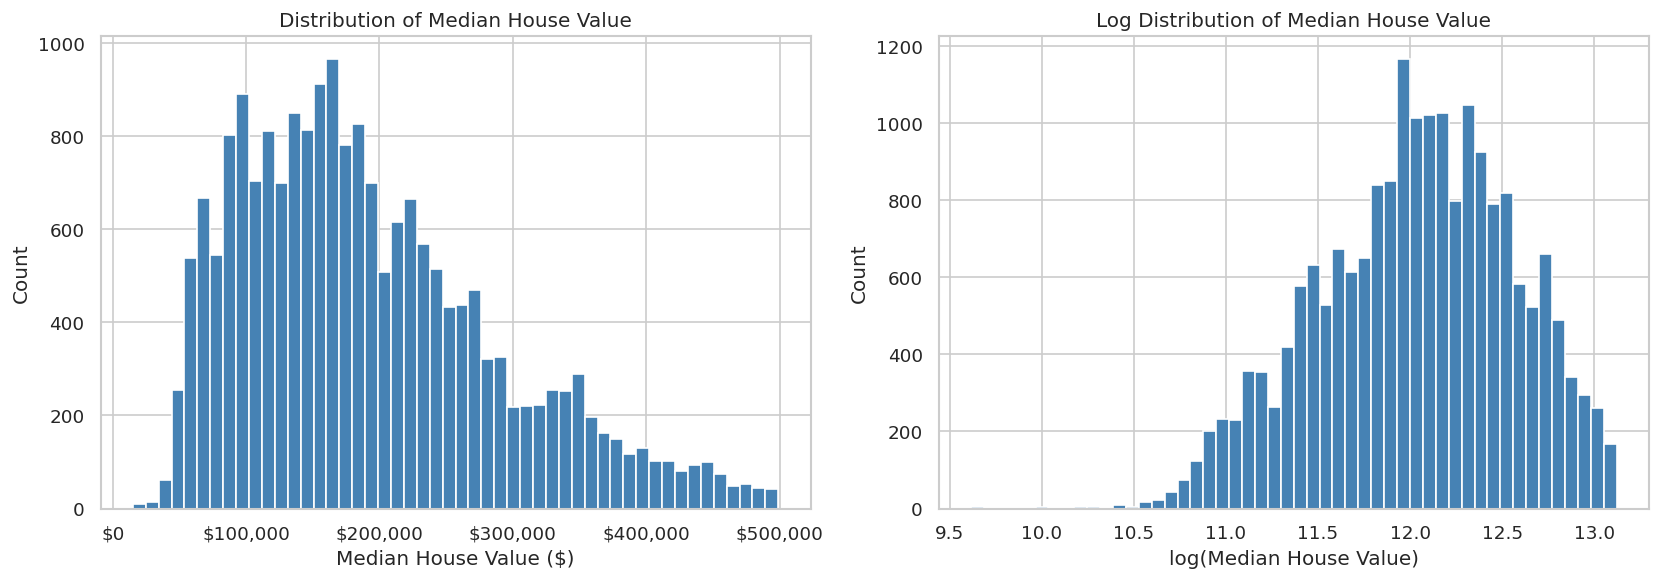

In [6]:
# --- 4.2 Target variable distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].hist(np.log1p(df['median_house_value']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Log Distribution of Median House Value')
axes[1].set_xlabel('log(Median House Value)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

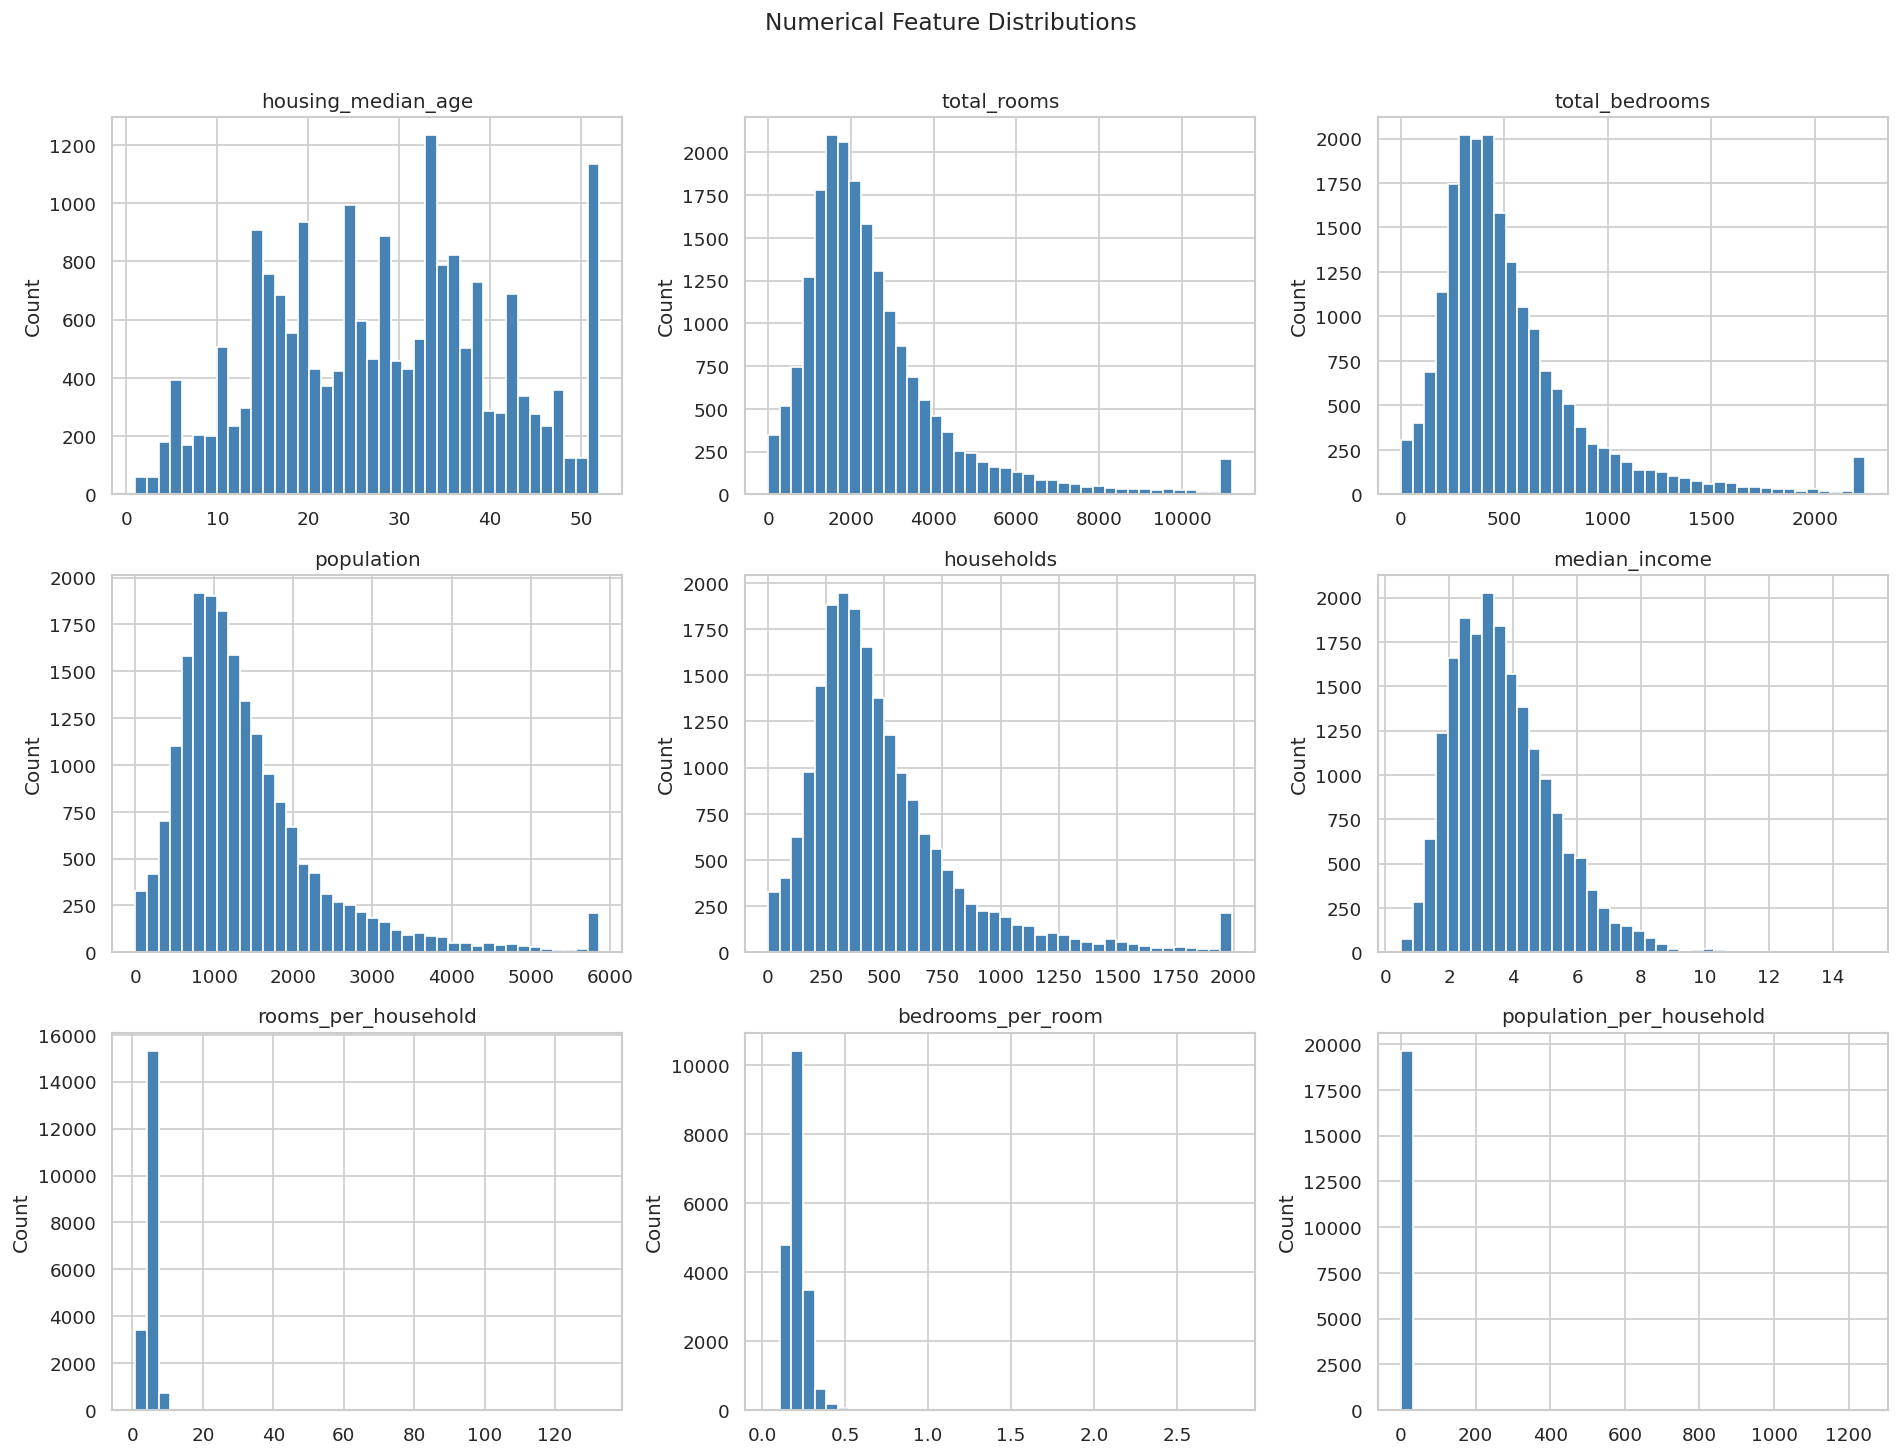

In [7]:
# --- 4.3 Numerical features distributions ---
num_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms',
            'population', 'households', 'median_income',
            'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

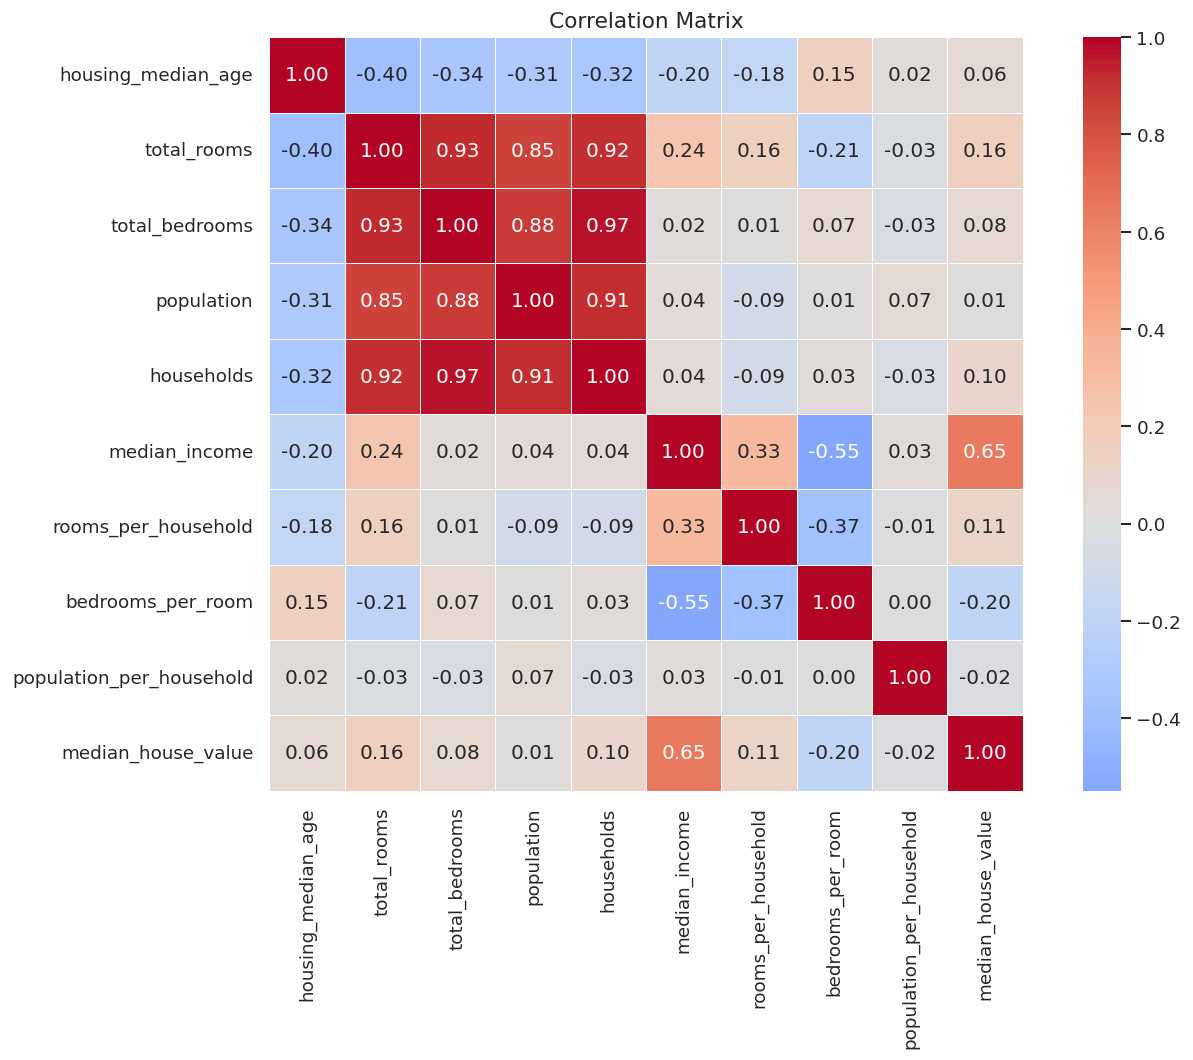

In [8]:
# --- 4.4 Correlation heatmap ---
corr_cols = num_cols + ['median_house_value']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

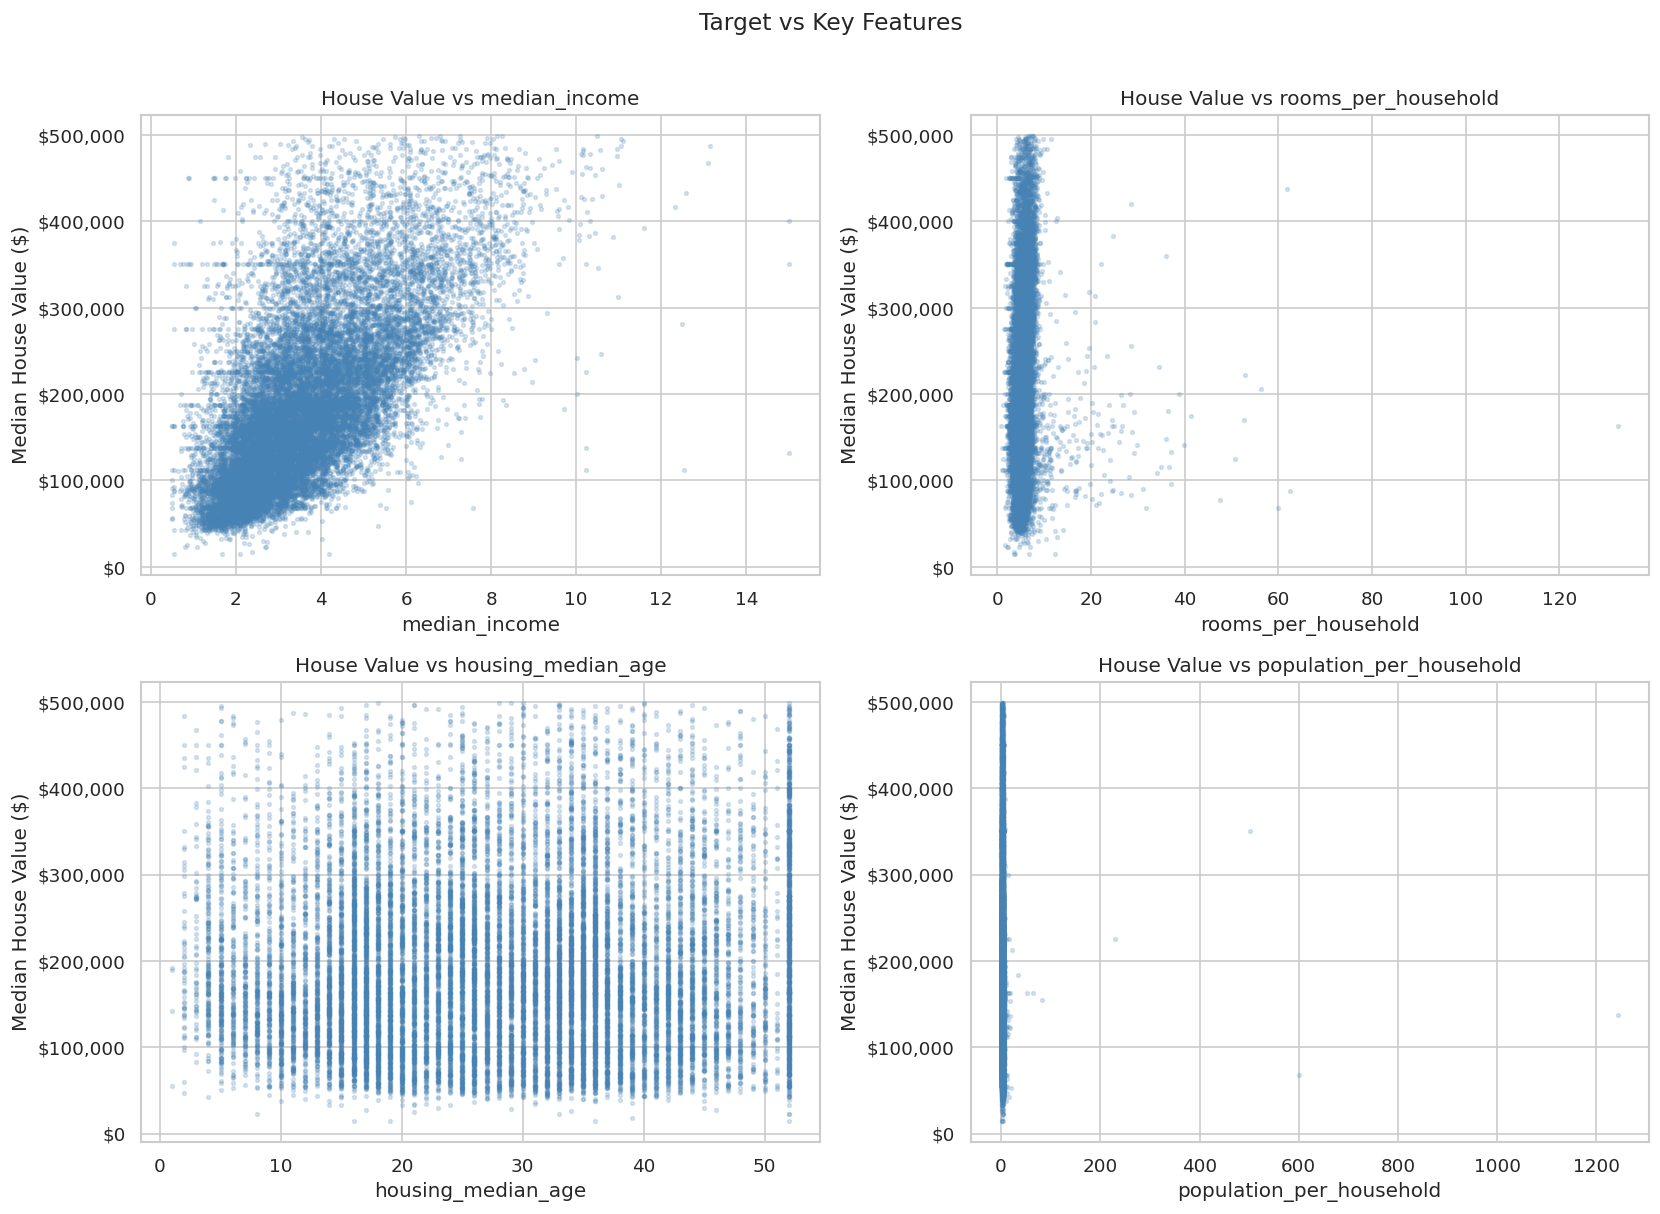

In [9]:
# --- 4.5 Target vs key features (scatter) ---
key_features = ['median_income', 'rooms_per_household',
                'housing_median_age', 'population_per_household']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].scatter(df[col], df['median_house_value'],
                    alpha=0.2, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Median House Value ($)')
    axes[i].set_title(f'House Value vs {col}')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Target vs Key Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('scatter_target_vs_features.png', dpi=150, bbox_inches='tight')
plt.show()

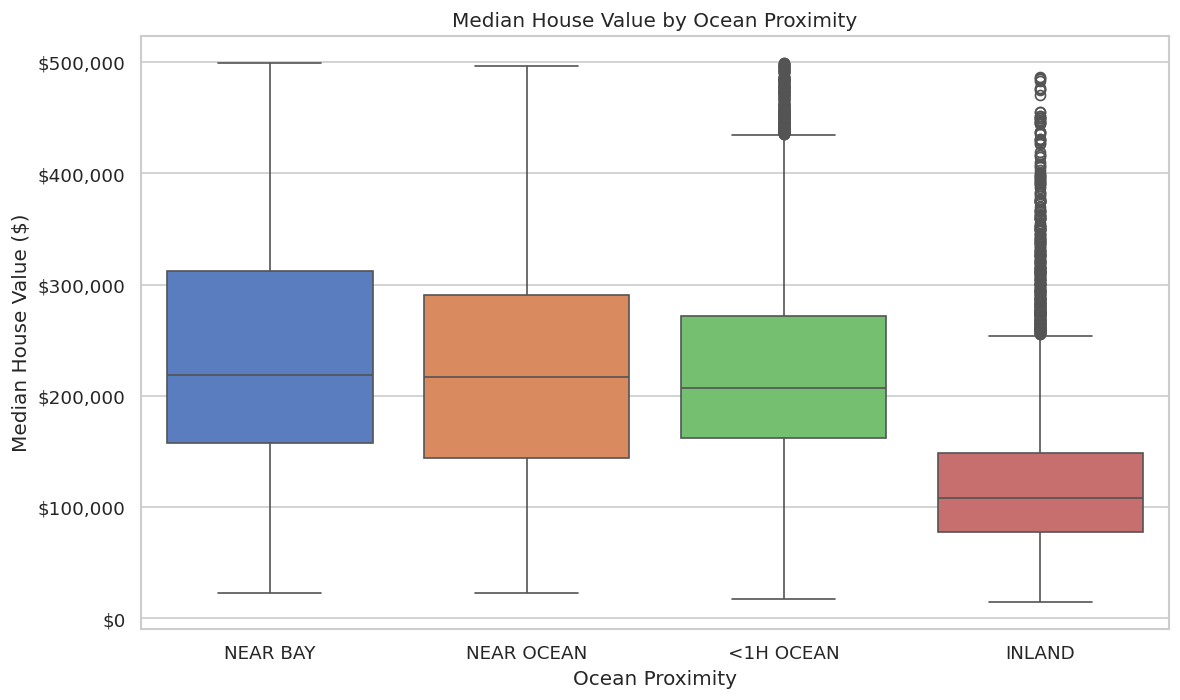

In [10]:
# --- 4.6 Target by ocean proximity (boxplot) ---
fig, ax = plt.subplots(figsize=(10, 6))

order = df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df,
    x='ocean_proximity',
    y='median_house_value',
    order=order,
    palette='muted',
    ax=ax
)
ax.set_title('Median House Value by Ocean Proximity')
ax.set_xlabel('Ocean Proximity')
ax.set_ylabel('Median House Value ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('boxplot_ocean_proximity.png', dpi=150, bbox_inches='tight')
plt.show()

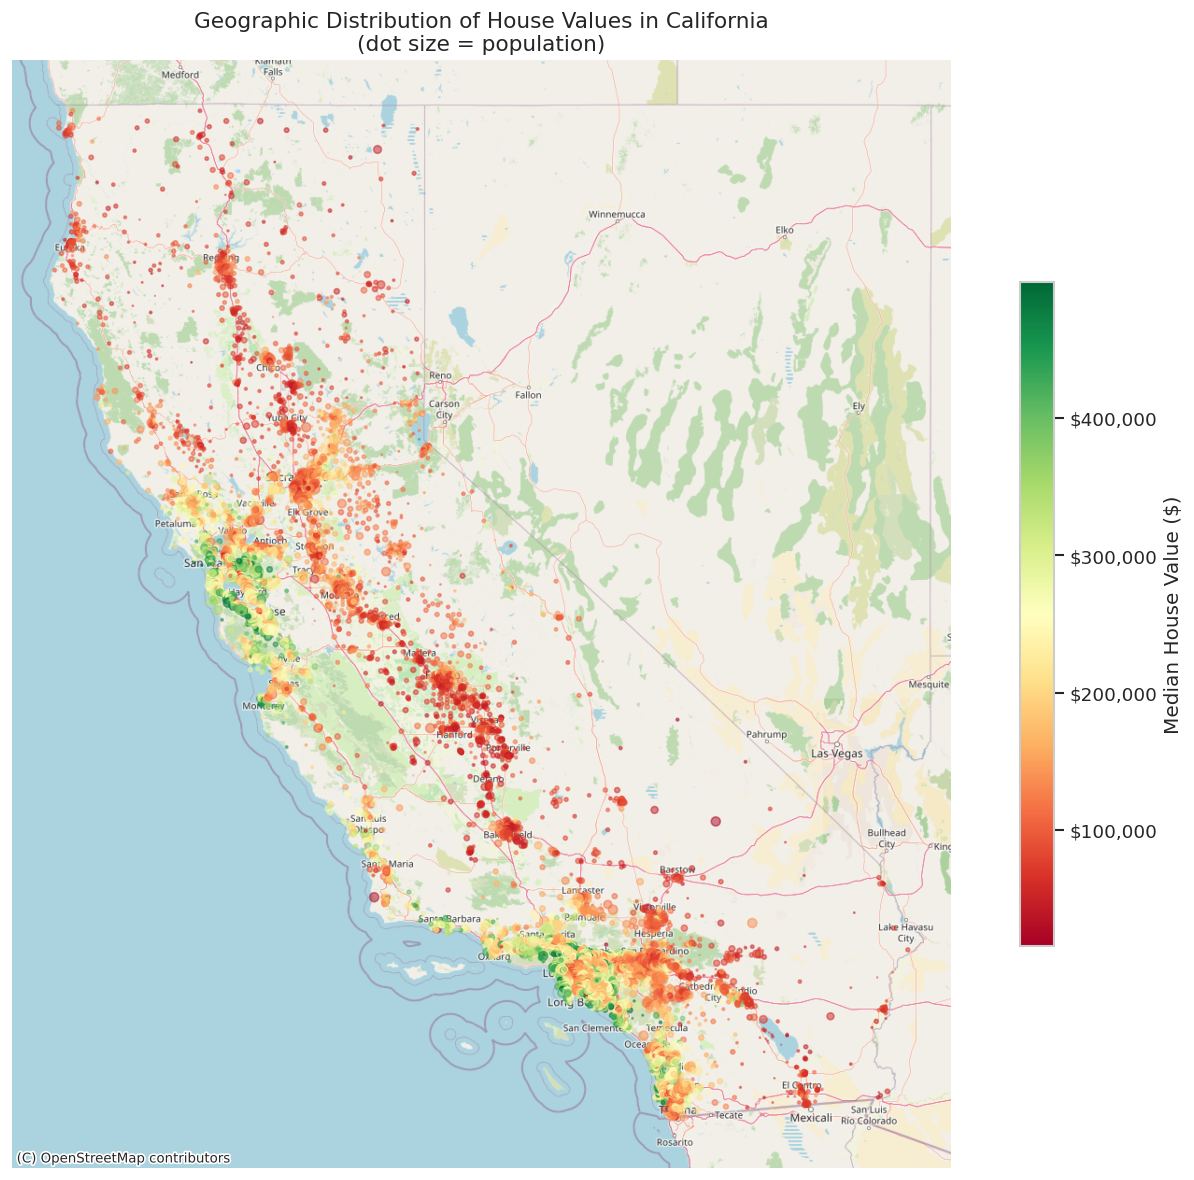

In [12]:
# ============================================================
# CELL 4.7 - GEOGRAPHIC MAP WITH REAL BASEMAP
# ============================================================

# Install required libraries (run once)
!pip install contextily geopandas -q

import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

# --- Convert dataframe to GeoDataFrame ---
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

# Reproject to Web Mercator (required by contextily)
gdf = gdf.to_crs(epsg=3857)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    ax=ax,
    column='median_house_value',
    cmap='RdYlGn',
    alpha=0.5,
    markersize=gdf['population'] / 200,
    legend=True,
    legend_kwds={
        'label': 'Median House Value ($)',
        'orientation': 'vertical',
        'shrink': 0.6,
        'format': mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
    }
)

# Add OpenStreetMap basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=7
)

ax.set_title('Geographic Distribution of House Values in California\n(dot size = population)',
             fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('geo_map_real.png', dpi=150, bbox_inches='tight')
plt.show()